# Module #1 - Compound data acquisition using ChEMBL
Authors:

- Svetlana Leng, CADD seminar 2017, Volkamer lab, Charité/FU Berlin 
- Paula Junge, CADD seminar 2018, Volkamer lab, Charité/FU Berlin
- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)

__Module 1__: This Module is part of the TeachOpenCADD pipeline described in the [first TeachOpenCADD paper](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x), comprising of talktorials T001-T010.

## Aim of this Module

In this Module, we will work to find compounds that were tested against a certain target and filter available bioactivity data.

### References

* ChEMBL bioactivity database: [Gaulton *et al.*, <i>Nucleic Acids Res.</i> (2017), 45(Database issue), D945–D954](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5210557/)
* ChEMBL web services: [Davies *et al.*, <i>Nucleic Acids Res.</i> (2015), <b>43</b>, 612-620](https://academic.oup.com/nar/article/43/W1/W612/2467881) 
* [ChEMBL web-interface](https://www.ebi.ac.uk/chembl/)
*  GitHub [ChEMBL web rescource client](https://github.com/chembl/chembl_webresource_client)
* The EBI RDF platform: [Jupp *et al.*, <i>Bioinformatics </i> (2014), 30(9), 1338-9](https://www.ncbi.nlm.nih.gov/pubmed/24413672)
* Info on half maximal inhibitory concentration: [(p)IC50](https://en.wikipedia.org/wiki/IC50)
* [UniProt website](https://www.uniprot.org/)

## Practical

In the following, we will download all molecules that have been tested against our target of interest, the **PAK1** ([**PAK1**](https://www.uniprot.org/uniprot/Q13153)) kinase.

### Connect to ChEMBL database

First, the ChEMBL web resource client as well as other Python libraries are imported.

In [1]:
import math
from pathlib import Path
from zipfile import ZipFile
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
from rdkit.Chem import PandasTools
from chembl_webresource_client.new_client import new_client
from tqdm.auto import tqdm

In [2]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

Next, we create resource objects for API access.

In [3]:
targets_api = new_client.target
compounds_api = new_client.molecule
bioactivities_api = new_client.activity

In [4]:
type(targets_api)

chembl_webresource_client.query_set.QuerySet

### Get target data (PAK1 kinase)

* Get UniProt ID of the target of interest (PAK1 - p21-activated kinase 1):  [Q13152](http://www.uniprot.org/uniprot/Q13153)) from [UniProt website](https://www.uniprot.org/)
* Use UniProt ID to get target information

In [5]:
uniprot_id = "Q13153"

#### Fetch target data from ChEMBL

In [6]:
# Get target information from ChEMBL but restrict it to specified values only
targets = targets_api.get(target_components__accession=uniprot_id).only(
    "target_chembl_id", "organism", "pref_name", "target_type"
)
print(f'The type of the targets is "{type(targets)}"')

The type of the targets is "<class 'chembl_webresource_client.query_set.QuerySet'>"


#### Download target data from ChEMBL

The results of the query are stored in `targets`, a `QuerySet`, i.e. the results are not fetched from ChEMBL until we ask for it (here using `pandas.DataFrame.from_records`).

More information about the `QuerySet` datatype:

> QuerySets are lazy – the act of creating a QuerySet does not involve any database activity. You can stack filters together all day long, and Django will actually not run the query until the QuerySet is evaluated. 
([querysets-are-lazy](https://docs.djangoproject.com/en/3.0/topics/db/queries/#querysets-are-lazy))

In [7]:
targets = pd.DataFrame.from_records(targets)
targets

,organism,pref_name,target_chembl_id,target_type
0,Homo sapiens,Serine/threonine-protein kinase PAK 1,CHEMBL4600,SINGLE PROTEIN
1,Homo sapiens,Serine/threonine-protein kinase PAK 1,CHEMBL4600,SINGLE PROTEIN
2,Homo sapiens,Serine/threonine-protein kinase PAK 1/PAK 2,CHEMBL3885636,PROTEIN FAMILY
3,Homo sapiens,Serine/threonine-protein kinase PAK 1/PAK 2/PAK 3,CHEMBL3885637,PROTEIN FAMILY
4,Homo sapiens,PAK 1/CDC42,CHEMBL4296113,PROTEIN COMPLEX
5,Homo sapiens,Cereblon/Serine/threonine-protein kinase PAK 1,CHEMBL5291682,PROTEIN-PROTEIN INTERACTION


#### Select target (target ChEMBL ID)

After checking the entries, we select the first entry as our target of interest:

`CHEMBL4600`: It is a single protein and represents the human Serine/threonine-protein kinase (PAK 1)

In [8]:
target = targets.iloc[0]
target

organism                                     Homo sapiens
pref_name           Serine/threonine-protein kinase PAK 1
target_chembl_id                               CHEMBL4600
target_type                                SINGLE PROTEIN
Name: 0, dtype: object

Save selected ChEMBL ID.

In [9]:
chembl_id = target.target_chembl_id
print(f"The target ChEMBL ID is {chembl_id}")
# NBVAL_CHECK_OUTPUT

The target ChEMBL ID is CHEMBL4600


### Get bioactivity data

Now, we want to query bioactivity data for the target of interest.

#### Fetch bioactivity data for the target from ChEMBL

In this step, we fetch the bioactivity data and filter it to only consider

* human proteins, 
* bioactivity type IC50, 
* exact measurements (relation `'='`), and
* binding data (assay type `'B'`).

In [10]:
bioactivities = bioactivities_api.filter(
    target_chembl_id=chembl_id, type="IC50", relation="=", assay_type="B"
).only(
    "activity_id",
    "assay_chembl_id",
    "assay_description",
    "assay_type",
    "molecule_chembl_id",
    "type",
    "standard_units",
    "relation",
    "standard_value",
    "target_chembl_id",
    "target_organism",
)

print(f"Length and type of bioactivities object: {len(bioactivities)}, {type(bioactivities)}")

Length and type of bioactivities object: 286, <class 'chembl_webresource_client.query_set.QuerySet'>


Each entry in our bioactivity set holds the following information:

In [11]:
print(f"Length and type of first element: {len(bioactivities[0])}, {type(bioactivities[0])}")
bioactivities[0]

Length and type of first element: 13, <class 'dict'>


{'activity_id': 2114124,
 'assay_chembl_id': 'CHEMBL935260',
 'assay_description': 'Inhibition of PAK1',
 'assay_type': 'B',
 'molecule_chembl_id': 'CHEMBL271139',
 'relation': '=',
 'standard_units': 'nM',
 'standard_value': '18000.0',
 'target_chembl_id': 'CHEMBL4600',
 'target_organism': 'Homo sapiens',
 'type': 'IC50',
 'units': 'uM',
 'value': '18.0'}

#### Download bioactivity data from ChEMBL

Finally, we download the `QuerySet` in the form of a `pandas` `DataFrame`. 

> **Note**: This step should not take more than 2 minutes, if so try to rerun all cells starting from _"Fetch bioactivity data for the target from ChEMBL"_ or read this message below:

<details>
    
<summary>Load a local version of the data (in case you encounter any problems while fetching the data)</summary>
    
If you experience difficulties to query the ChEMBL database, we also provide the resulting dataframe you will construct in the cell below. If you want to use the saved version, use the following code instead to obtain `bioactivities_df`:
  
```python
# replace first line in cell below with this other line
bioactivities_df = pd.read_csv(DATA / "EGFR_bioactivities_CHEMBL27.csv.zip", index_col=0)
```

</details>

In [12]:
bioactivities_df = pd.DataFrame.from_dict(bioactivities)
print(f"DataFrame shape: {bioactivities_df.shape}")
bioactivities_df.head()

DataFrame shape: (286, 13)


,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type,units,value
0,2114124,CHEMBL935260,Inhibition of PAK1,B,CHEMBL271139,=,nM,18000.0,CHEMBL4600,Homo sapiens,IC50,uM,18.0
1,2114125,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259041,=,nM,38000.0,CHEMBL4600,Homo sapiens,IC50,uM,38.0
2,2114126,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259040,=,nM,31000.0,CHEMBL4600,Homo sapiens,IC50,uM,31.0
3,2114127,CHEMBL935260,Inhibition of PAK1,B,CHEMBL408244,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50,uM,23.0
4,2114128,CHEMBL935260,Inhibition of PAK1,B,CHEMBL407278,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50,uM,23.0


Note that the first two rows describe the same bioactivity entry; we will remove such artifacts later during the deduplication step. Note also that we have columns for `standard_units`/`units` and `standard_values`/`values`; in the following, we will use the standardized columns (standardization by ChEMBL), and thus, we drop the other two columns.

If we used the `units` and `values` columns, we would need to convert all values with many different units to nM:

In [13]:
bioactivities_df["units"].unique()

array(['uM', 'nM', "10'-10M", '10^-10M'], dtype=object)

In [14]:
bioactivities_df.drop(["units", "value"], axis=1, inplace=True)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type
0,2114124,CHEMBL935260,Inhibition of PAK1,B,CHEMBL271139,=,nM,18000.0,CHEMBL4600,Homo sapiens,IC50
1,2114125,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259041,=,nM,38000.0,CHEMBL4600,Homo sapiens,IC50
2,2114126,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259040,=,nM,31000.0,CHEMBL4600,Homo sapiens,IC50
3,2114127,CHEMBL935260,Inhibition of PAK1,B,CHEMBL408244,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50
4,2114128,CHEMBL935260,Inhibition of PAK1,B,CHEMBL407278,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50


#### Preprocess and filter bioactivity data

1. Convert `standard_value`'s datatype from `object` to `float`
2. Delete entries with missing values
3. Keep only entries with `standard_unit == nM`
4. Delete duplicate molecules
5. Reset `DataFrame` index
6. Rename columns

**1. Convert datatype of "standard_value" from "object" to "float"**

The field `standard_value` holds standardized (here IC50) values. In order to make these values usable in calculations later on, convert values to floats.

In [15]:
bioactivities_df.dtypes

activity_id            int64
assay_chembl_id       object
assay_description     object
assay_type            object
molecule_chembl_id    object
relation              object
standard_units        object
standard_value        object
target_chembl_id      object
target_organism       object
type                  object
dtype: object

In [16]:
bioactivities_df = bioactivities_df.astype({"standard_value": "float64"})
bioactivities_df.dtypes

activity_id             int64
assay_chembl_id        object
assay_description      object
assay_type             object
molecule_chembl_id     object
relation               object
standard_units         object
standard_value        float64
target_chembl_id       object
target_organism        object
type                   object
dtype: object

**2. Delete entries with missing values**

Use the parameter `inplace=True` to drop values in the current `DataFrame` directly.

In [17]:
bioactivities_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (286, 11)


**3. Keep only entries with "standard_unit == nM"** 

We only want to keep bioactivity entries in `nM`, thus we remove all entries with other units.

In [18]:
print(f"Units in downloaded data: {bioactivities_df['standard_units'].unique()}")
print(
    f"Number of non-nM entries:\
    {bioactivities_df[bioactivities_df['standard_units'] != 'nM'].shape[0]}"
)

Units in downloaded data: ['nM']
Number of non-nM entries:    0


In [19]:
bioactivities_df = bioactivities_df[bioactivities_df["standard_units"] == "nM"]
print(f"Units after filtering: {bioactivities_df['standard_units'].unique()}")

Units after filtering: ['nM']


In [20]:
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (286, 11)


**4. Delete duplicate molecules**

Sometimes the same molecule (`molecule_chembl_id`) has been tested more than once, in this case, we only keep the first one.

Note other choices could be to keep the one with the best value or a mean value of all assay results for the respective compound.

In [21]:
bioactivities_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (237, 11)


**5. Reset "DataFrame" index**

Since we deleted some rows, but we want to iterate over the index later, we reset the index to be continuous.

In [22]:
bioactivities_df.reset_index(drop=True, inplace=True)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type
0,2114124,CHEMBL935260,Inhibition of PAK1,B,CHEMBL271139,=,nM,18000.0,CHEMBL4600,Homo sapiens,IC50
1,2114125,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259041,=,nM,38000.0,CHEMBL4600,Homo sapiens,IC50
2,2114126,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259040,=,nM,31000.0,CHEMBL4600,Homo sapiens,IC50
3,2114127,CHEMBL935260,Inhibition of PAK1,B,CHEMBL408244,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50
4,2114128,CHEMBL935260,Inhibition of PAK1,B,CHEMBL407278,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50


**6. Rename columns**

In [23]:
bioactivities_df.rename(
    columns={"standard_value": "IC50", "standard_units": "units"}, inplace=True
)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,units,IC50,target_chembl_id,target_organism,type
0,2114124,CHEMBL935260,Inhibition of PAK1,B,CHEMBL271139,=,nM,18000.0,CHEMBL4600,Homo sapiens,IC50
1,2114125,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259041,=,nM,38000.0,CHEMBL4600,Homo sapiens,IC50
2,2114126,CHEMBL935260,Inhibition of PAK1,B,CHEMBL259040,=,nM,31000.0,CHEMBL4600,Homo sapiens,IC50
3,2114127,CHEMBL935260,Inhibition of PAK1,B,CHEMBL408244,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50
4,2114128,CHEMBL935260,Inhibition of PAK1,B,CHEMBL407278,=,nM,23000.0,CHEMBL4600,Homo sapiens,IC50


In [24]:
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (237, 11)


We now have a set of **237** molecule ids with respective IC50 values for our target kinase.

### Get compound data

We have a `DataFrame` containing all molecules tested against PAK1 (with the respective measured bioactivity). 

Now, we want to get the molecular structures of the molecules that are linked to respective bioactivity ChEMBL IDs. 

#### Fetch compound data from ChEMBL

Let's have a look at the compounds from ChEMBL which we have defined bioactivity data for: We fetch compound ChEMBL IDs and structures for the compounds linked to our filtered bioactivity data.

In [25]:
compounds_provider = compounds_api.filter(
    molecule_chembl_id__in=list(bioactivities_df["molecule_chembl_id"])
).only("molecule_chembl_id", "molecule_structures")

#### Download compound data from ChEMBL

Again, we want to export the `QuerySet` object into a `pandas.DataFrame`. Given the data volume, **this can take some time.** For that reason, we will first obtain the list of records through `tqdm`, so we get a nice progress bar and some ETAs. We can then pass the list of compounds to the DataFrame.

In [26]:
compounds = list(tqdm(compounds_provider))

  0%|          | 0/237 [00:00<?, ?it/s]

In [27]:
compounds_df = pd.DataFrame.from_records(
    compounds,
)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (237, 2)


In [28]:
compounds_df.head()

,molecule_chembl_id,molecule_structures
0,CHEMBL469,{'canonical_smiles': 'O=C(c1ccccc1)c1ccc2n1CCC...
1,CHEMBL140,{'canonical_smiles': 'COc1cc(/C=C/C(=O)CC(=O)/...
2,CHEMBL165,{'canonical_smiles': 'Oc1ccc(/C=C/c2cc(O)cc(O)...
3,CHEMBL388978,{'canonical_smiles': 'CN[C@@H]1C[C@H]2O[C@@](C...
4,CHEMBL259040,{'canonical_smiles': 'c1nc2cnc(NC3CCCCC3)nc2[n...


#### Preprocess and filter compound data

1. Remove entries with missing entries
2. Delete duplicate molecules (by molecule_chembl_id)
3. Get molecules with canonical SMILES

**1. Remove entries with missing molecule structure entry**

In [29]:
compounds_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (237, 2)


**2. Delete duplicate molecules**

In [30]:
compounds_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (237, 2)


**3. Get molecules with canonical SMILES**

So far, we have multiple different molecular structure representations. We only want to keep the canonical SMILES.

In [31]:
compounds_df.iloc[0].molecule_structures.keys()

dict_keys(['canonical_smiles', 'molfile', 'standard_inchi', 'standard_inchi_key'])

In [32]:
canonical_smiles = []

for i, compounds in compounds_df.iterrows():
    try:
        canonical_smiles.append(compounds["molecule_structures"]["canonical_smiles"])
    except KeyError:
        canonical_smiles.append(None)

compounds_df["smiles"] = canonical_smiles
compounds_df.drop("molecule_structures", axis=1, inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (237, 2)


Sanity check: Remove all molecules without a canonical SMILES string.

In [33]:
compounds_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (237, 2)


### Output (bioactivity-compound) data
**Summary of compound and bioactivity data**

In [34]:
print(f"Bioactivities filtered: {bioactivities_df.shape[0]}")
bioactivities_df.columns

Bioactivities filtered: 237


Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'molecule_chembl_id', 'relation', 'units', 'IC50', 'target_chembl_id',
       'target_organism', 'type'],
      dtype='object')

In [35]:
print(f"Compounds filtered: {compounds_df.shape[0]}")
compounds_df.columns

Compounds filtered: 237


Index(['molecule_chembl_id', 'smiles'], dtype='object')

#### Merge both datasets

Merge values of interest from `bioactivities_df` and `compounds_df` in an `output_df` based on the compounds' ChEMBL IDs (`molecule_chembl_id`), keeping the following columns:

* ChEMBL IDs: `molecule_chembl_id`
* SMILES: `smiles`
* units: `units`
* IC50: `IC50`

In [36]:
# Merge DataFrames
output_df = pd.merge(
    bioactivities_df[["molecule_chembl_id", "IC50", "units"]],
    compounds_df,
    on="molecule_chembl_id",
)

# Reset row indices
output_df.reset_index(drop=True, inplace=True)

print(f"Dataset with {output_df.shape[0]} entries.")

Dataset with 237 entries.


In [37]:
output_df.dtypes

molecule_chembl_id     object
IC50                  float64
units                  object
smiles                 object
dtype: object

In [38]:
output_df.head(10)

,molecule_chembl_id,IC50,units,smiles
0,CHEMBL271139,18000.0,nM,c1nc(NC2CCCC2)c2nc[nH]c2n1
1,CHEMBL259041,38000.0,nM,CCCCCSc1ncnc2[nH]cnc12
2,CHEMBL259040,31000.0,nM,c1nc2cnc(NC3CCCCC3)nc2[nH]1
3,CHEMBL408244,23000.0,nM,CC(Sc1ncnc2[nH]cnc12)c1ccccc1Cl
4,CHEMBL407278,23000.0,nM,CC1CC(Nc2ncnc3[nH]cnc23)CC(C)(C)C1
5,CHEMBL271138,18000.0,nM,c1nc(N2CCOCC2)c2nc[nH]c2n1
6,CHEMBL590109,510.0,nM,NCCn1cc(-c2cc(-c3cc4ccccc4s3)c3[nH]ncc3c2)c2nc...
7,CHEMBL593490,31.0,nM,Cc1[nH]nc2ccc(-c3cc(OC[C@@H](N)Cc4c[nH]c5ccccc...
8,CHEMBL1090360,531.0,nM,O=C(Cc1ccccc1)Nc1cccc(-c2nc3sccn3c2-c2ccnc(Nc3...
9,CHEMBL2386715,64.1,nM,COCCN(Cc1cc(F)cc2[nH]ncc12)c1nccc(Nc2cc(C3CC3)...


#### Add pIC50 values

As you can see the low IC50 values are difficult to read (values are distributed over multiple scales), which is why we convert the IC50 values to pIC50.

In [39]:
def convert_ic50_to_pic50(IC50_value):
    pIC50_value = 9 - math.log10(IC50_value)
    return pIC50_value

In [40]:
# Apply conversion to each row of the compounds DataFrame
output_df["pIC50"] = output_df.apply(lambda x: convert_ic50_to_pic50(x.IC50), axis=1)

In [41]:
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL271139,18000.0,nM,c1nc(NC2CCCC2)c2nc[nH]c2n1,4.744727
1,CHEMBL259041,38000.0,nM,CCCCCSc1ncnc2[nH]cnc12,4.420216
2,CHEMBL259040,31000.0,nM,c1nc2cnc(NC3CCCCC3)nc2[nH]1,4.508638
3,CHEMBL408244,23000.0,nM,CC(Sc1ncnc2[nH]cnc12)c1ccccc1Cl,4.638272
4,CHEMBL407278,23000.0,nM,CC1CC(Nc2ncnc3[nH]cnc23)CC(C)(C)C1,4.638272


#### Draw compound data

Let's have a look at our collected data set.

First, we plot the pIC50 value distribution

array([[<Axes: title={'center': 'pIC50'}>]], dtype=object)

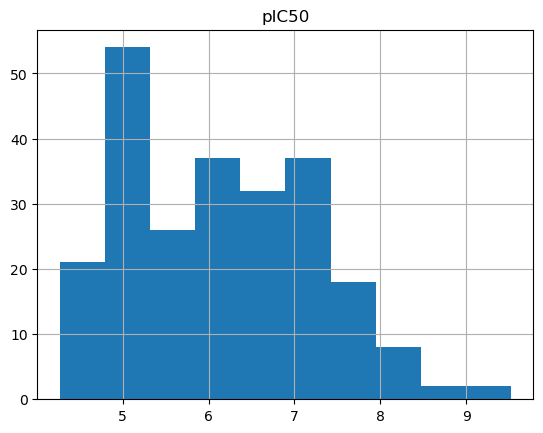

In [42]:
output_df.hist(column="pIC50")

In the next steps, we add a column for RDKit molecule objects to our `DataFrame` and look at the structures of the molecules with the highest pIC50 values. 

In [43]:
# Add molecule column
PandasTools.AddMoleculeColumnToFrame(output_df, smilesCol="smiles")

In [44]:
# Sort molecules by pIC50
output_df.sort_values(by="pIC50", ascending=False, inplace=True)

# Reset index
output_df.reset_index(drop=True, inplace=True)

Show the three most active molecules, i.e. molecules with the highest pIC50 values.

In [45]:
output_df.drop("smiles", axis=1).head(3)

,molecule_chembl_id,IC50,units,pIC50,ROMol
0,CHEMBL388978,0.3,nM,9.522879,<rdkit.Chem.rdchem.Mol object at 0x000001CCA3D...
1,CHEMBL3597011,1.0,nM,9.000000,<rdkit.Chem.rdchem.Mol object at 0x000001CCA3D...
2,CHEMBL3597013,2.8,nM,8.552842,<rdkit.Chem.rdchem.Mol object at 0x000001CCA3D...


In [46]:
# Prepare saving the dataset: Drop the ROMol column
output_df = output_df.drop("ROMol", axis=1)
print(f"DataFrame shape: {output_df.shape}")

DataFrame shape: (237, 5)


#### Write output data to file

We want to use this bioactivity-compound dataset in the following Modules, thus we save the data as `csv` file. 
Note that it is advisable to drop the molecule column (which only contains an image of the molecules) when saving the data.

In [47]:
output_df.to_csv(DATA / "PAK1_compounds.csv")
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL388978,0.3,nM,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,9.522879
1,CHEMBL3597011,1.0,nM,CN1CCc2cc(-c3cnc4[nH]cc(C(=O)c5ccccc5Cl)c4c3)c...,9.000000
2,CHEMBL3597013,2.8,nM,CCn1c(Nc2ccc(N3CCN(C)CC3)cc2)ncc(-c2ccc(-c3cnc...,8.552842
3,CHEMBL3596921,3.0,nM,O=C(c1ccc(COc2ccccc2)cc1Cl)c1c[nH]c2ncc(-c3cnn...,8.522879
4,CHEMBL3596932,4.5,nM,CN1CCc2ccc(-c3cnc4[nH]cc(C(=O)c5ccccc5Cl)c4c3)...,8.346787


In [48]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (237, 5)


## Discussion

In this tutorial, we collected bioactivity data for our target of interest from the ChEMBL database. 
We filtered the data set in order to only contain molecules with measured IC50 bioactivity values. 

Be aware that ChEMBL data originates from various sources. Compound data has been generated in different labs by different people all over the world. Therefore, we have to be cautious with the predictions we make using this data set. It is always important to consider the source of the data and consistency of data production assays when interpreting the results and determining how much confidence we have in our predictions.